In [1]:
# BENTCHMARK CASES
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras




from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure2 import *
from pathlib import Path



"""
Tutorial for the creation of multifidelity Neural Networks
"""

# # path to the current notebook
# current_file_path = Path().resolve()
# # path to the current folder
# load_context_functions(current_file_path.parent.name)



# # fixing the seeds for reproducibility purposes
# seed = 10
# tf.random.set_seed(seed)
# np.random.seed(seed)
# keras.utils.set_random_seed(seed)


import numpy as np
import inspect
from matplotlib import pyplot as plt
from typing import Dict, Any

class FidelityFunctions:
    def __init__(self, case: str, **kwargs: Any) -> None:
        """
        Initializes the FidelityFunctions object with a specified case and optional parameters.

        :param case: The case to use ('Basic', 'Discontinuous', or 'Oscillatory').
        :param kwargs: Additional parameters to override defaults for the specified case.
        """
        self.cases = {
            "Basic": {
                "high_fid": self.high_fidelity_basic,
                "low_fid": self.low_fidelity_basic,
                "Nhf": 5,
                "Nlf": 32,
                "NepoLF": 1000,
                "NepoHF": 500
            },
            "Discontinuous": {
                "high_fid": self.high_fidelity_discontinuous,
                "low_fid": self.low_fidelity_discontinuous,
                "Nhf": 6,
                "Nlf": 32,
                "NepoLF": 5000,
                "NepoHF": 1200
            },
            "Oscillatory": {
                "high_fid": self.high_fidelity_oscillatory,
                "low_fid": self.low_fidelity_oscillatory,
                "Nhf": 15,
                "Nlf": 64,
                "NepoLF": 3000,
                "NepoHF": 3000
            }
        }
        if case not in self.cases:
            raise ValueError(f"Example {case} not recognized")
        
        self.data = self.cases[case]
        self.data.update(kwargs)
        self.evaluate_case_data()

    @staticmethod
    def high_fidelity_basic(x: np.ndarray) -> np.ndarray:
        """
        High fidelity function for the 'Basic' case.
        
        :param x: Input array.
        :return: Calculated high fidelity values.
        """
        return (6.*x/5-2.)**2 * np.sin(12.*x/5-4.)

    @staticmethod
    def low_fidelity_basic(x: np.ndarray) -> np.ndarray:
        """
        Low fidelity function for the 'Basic' case.
        
        :param x: Input array.
        :return: Calculated low fidelity values.
        """
        return 0.5 * FidelityFunctions.high_fidelity_basic(x) + 10 * (x/5-0.5) + 5.

    @staticmethod
    def high_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        High fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated high fidelity values.
        """    
        lowfid = FidelityFunctions.low_fidelity_discontinuous(x)
        return (2*lowfid - 20*x/5 + 20) * (x/5 < 0.5) + (4 + 2*lowfid - 20*x/5 + 20) * (x/5 > 0.5)

    @staticmethod
    def low_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        Low fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated low fidelity values.
        """
        return (0.5 * (6.*x/5.-2.)**2 * np.sin(12.*x/5.-4) + 10.*(x/5-0.5) - 5.) * (x < 2.5) + \
               (3 + 0.5 * (6.*x/5.-2)**2 * np.sin(12.*x/5.-4) + 10 * (x/5.-0.5) - 5.) * (x > 2.5)

    @staticmethod
    def high_fidelity_oscillatory(x: np.ndarray) -> np.ndarray:
        """
        High fidelity function for the 'Oscillatory' case.
        
        :param x: Input array.
        :return: Calculated high fidelity values.
        """
        lowfid = FidelityFunctions.low_fidelity_oscillatory(x)
        return (x/5 - np.sqrt(2)) * lowfid**2

    @staticmethod
    def low_fidelity_oscillatory(x: np.ndarray) -> np.ndarray:
        """
        Low fidelity function for the 'Oscillatory' case.
        
        :param x: Input array.
        :return: Calculated low fidelity values.
        """
        return np.sin(8 * np.pi * x / 5)

    @staticmethod
    def function_to_string(func: Any) -> str:
        """
        Converts a function to its string representation.

        :param func: The function to convert.
        :return: String representation of the function.
        """
        return inspect.getsource(func).strip()
    
    def plot_functions(self) -> None:
        """
        Plots the high fidelity and low fidelity functions along with their data points.
        """
        #data = self.get_data()
        xhf = self.data["xhf"]
        xlf = self.data["xlf"]
        x_test = self.data["x_test"]
        high_fid = self.data["high_fid"]
        low_fid = self.data["low_fid"]

        plt.figure()
        plt.plot(x_test, high_fid(x_test), 'r', label='high-fidelity sol')
        plt.plot(x_test, low_fid(x_test), 'g', label='low-fidelity sol')
        plt.plot(xhf, high_fid(xhf), 'ro', label='high-fidelity data', markersize=4)
        plt.plot(xlf, low_fid(xlf), 'go', label='low-fidelity data', markersize=4)
        plt.xlabel('x')
        plt.legend()
        plt.title('Benchmark 1D')
        plt.show()

    def evaluate_case_data(self) -> None:
        """
        Evaluates and stores the necessary data for the selected case.
        """
        Nhf = self.data["Nhf"]
        Nlf = self.data["Nlf"]
        self.data["xhf"] = np.linspace(0, 5, Nhf)
        self.data["xlf"] = np.linspace(0, 5, Nlf)
        self.data["x_test"] = np.linspace(0, 5, 1000)
        self.data["Yhf"] = self.data["high_fid"](self.data["xhf"])
        self.data["Ylf"] = self.data["low_fid"](self.data["xlf"])

    def get_data(self) -> Dict[str, Any]:
        """
        Returns the evaluated data for the selected case.

        :return: Dictionary containing evaluated data and function representations.
        """
        high_fid = self.data["high_fid"]
        low_fid = self.data["low_fid"]
        
        Yhf = self.data["Yhf"]
        Ylf = self.data["Ylf"]

        # return {
        #     "xhf dimensions": self.data["xhf"].shape[0],
        #     "xlf dimensions": self.data["xlf"].shape[0],
        #     "x_test dimensions": self.data["x_test"].shape[0],
        #     "Yhf dimensions": Yhf.shape[0],
        #     "Ylf dimensions": Ylf.shape[0],
        #     "NepoLF": self.data["NepoLF"],
        #     "NepoHF": self.data["NepoHF"],
        #     "high_fid_function": self.function_to_string(high_fid),
        #     "low_fid_function": self.function_to_string(low_fid)
        # }
        return self.data


def main():
    # path to the current notebook
    current_file_path = Path().resolve()
    # path to the current folder
    load_context_functions(current_file_path.parent.name)

    # introduction of a seed for reproducibility purposes
    seed = 10
    tf.random.set_seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)


    # Case to consider:
    example = "Discontinuous"
    fidelity_func = FidelityFunctions(example) #fidelity_func = FidelityFunctions(example, Nlf=40, NepoLF=6000)

    data = fidelity_func.get_data()

    # Print the functions in a readable format
    print("High Fidelity Function:\n", fidelity_func.function_to_string(data["high_fid"]), "\n")
    print("Low Fidelity Function:\n", fidelity_func.function_to_string(data["low_fid"]), "\n")
    #print(data)
    # Plot the functions
    fidelity_func.plot_functions()


    ### LOW FIDELITY NEURAL NETWORK ###
    bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
    definition_LF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xlf"],
        "output_train": data["Ylf"],
        "N": data["NepoLF"],
        "n": data["Nlf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
    modelLF=NetworkFactory.build_network(**definition_LF)
    yLF=modelLF.prediction(data["x_test"])
    (mse_LF,R_LF)=modelLF.performance(data["x_test"],data["high_fid"](data["x_test"]))


    ### HIGH FIDELITY NEURAL NETWORK ###
    bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
    definition_HF={
        "network_type": "LF",
        "params": bestHF_params,
        "data_train": data["xhf"],
        "output_train": data["Yhf"],
        "N": data["NepoHF"],
        "n": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
    modelHF=NetworkFactory.build_network(**definition_HF)
    yHF=modelHF.prediction(data["x_test"])
    (mse_HF,R_HF)=modelHF.performance(data["x_test"],data["high_fid"](data["x_test"]))


    ### 2 steps NEURAL NETWORK ###
    # collection of parameters
    bestLF_params = {
        'lr': 0.0255, 
        'kernel_init': 'glorot_uniform', 
        'opt': 'Adam'
    }
    
    best_params = {
        'kernel_init': 'uniform', 
        'l2weight': 0.00010018625799978436, 
        'lr': 0.07093837044166487, 
        'nodes': 74.0, 
        'opt': 'Adamax'
    }
    params = [bestLF_params, best_params]

    N = [data["NepoLF"], data["NepoHF"]]
    n = [data["Nlf"], data["Nhf"]]

    # names of the networks 
    names = ['LF', 'HF']

    # collection of the parameters
    definition_2steps = {
        "network_type": "2step",
        "names": names,
        "params": params,
        "data_train": [data["xlf"], data["xhf"]],
        "output_train": [data["Ylf"], data["Yhf"]],
        "N": N,
        "n": n,
        "train": True,
        "do_HPO": True,
        "verbose": False
    }


    # creation of 2 steps model 
    final_model = NetworkFactory.build_network(**definition_2steps)
    
    if final_model == -1:
        raise ValueError("Failed to build the network. Check the network type and parameters.")
    

    y_test = final_model.prediction(data["x_test"])

    # 2 steps performance 
    (mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))


    ### PLOT of predicted models ###
    #LF single-fidelity
    plt.figure()
    plt.plot(data["xlf"],data["Ylf"],'go', label = 'LF training data', markersize = 4)
    plt.plot(data["x_test"],data["low_fid"](data["x_test"]),'g', label = 'exact LF') 
    plt.plot(data["x_test"],yLF,'k--', label = 'pred LF')
    plt.legend()
    plt.title('Low fidelity model')

    #HF single-fidelity
    plt.figure()
    plt.plot(data["xhf"],data["Yhf"],'ro', label = 'HF training data')
    plt.plot(data["x_test"],data["high_fid"](data["x_test"]),'-r', label = 'exact HF')
    plt.plot(data["x_test"],yHF,'--k', label = 'pred HF')
    plt.legend()
    plt.title('High fidelity model - single-fidelity')

    #2-step MF
    plt.figure()
    plt.plot(data["xhf"],data["Yhf"],'ro', label = 'HF training data')
    plt.plot(data["x_test"],data["high_fid"](data["x_test"]),'-r', label = 'exact HF')
    plt.plot(data["x_test"],y_test,'--k', label = 'pred HF')
    plt.legend()
    plt.title('High fidelity model - 2-step')




High Fidelity Function:
 @staticmethod
    def high_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        High fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated high fidelity values.
        """    
        lowfid = FidelityFunctions.low_fidelity_discontinuous(x)
        return (2*lowfid - 20*x/5 + 20) * (x/5 < 0.5) + (4 + 2*lowfid - 20*x/5 + 20) * (x/5 > 0.5) 

Low Fidelity Function:
 @staticmethod
    def low_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        Low fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated low fidelity values.
        """
        return (0.5 * (6.*x/5.-2.)**2 * np.sin(12.*x/5.-4) + 10.*(x/5-0.5) - 5.) * (x < 2.5) + \
               (3 + 0.5 * (6.*x/5.-2)**2 * np.sin(12.*x/5.-4) + 10 * (x/5.-0.5) - 5.) * (x > 2.5) 



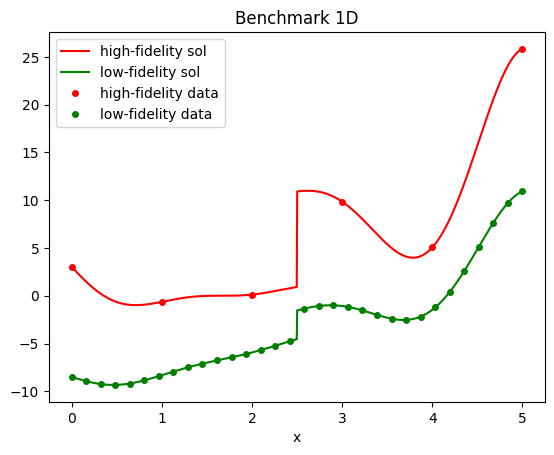

Function training took 12.9463 seconds
The function training took 12.946301221847534 seconds.


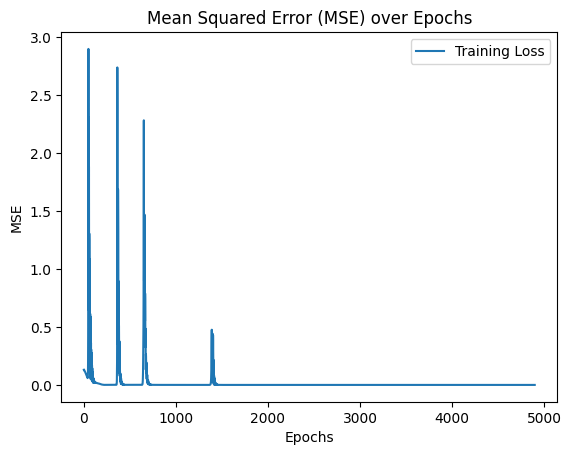

Function prediction took 0.1284 seconds
Function prediction took 0.0783 seconds
Test MSE: 82.28459782010431
R^2: -0.6799807891951397
Function training took 3.5163 seconds
The function training took 3.516251802444458 seconds.


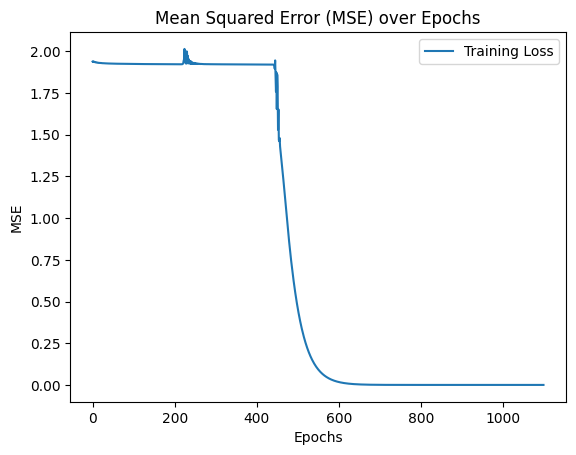

Function prediction took 0.1283 seconds
Function prediction took 0.0823 seconds
Test MSE: 3.500971598195358
R^2: 0.9285216773940531
1/1 [==============================] - 0s 54ms/step 

1/1 [==============================] - 0s 21ms/step 

1/1 [==============================] - 0s 22ms/step 

1/1 [==============================] - 0s 21ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 21ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 35ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 18ms/step 

1/1 [==============================] - 0s 18ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 21ms/step 

1/1 [==============================] - 0s 18ms/step 

1/1 [==============================] - 0s 18ms/step 

1/1 [==============================] - 0s 19ms/step 

1/1 

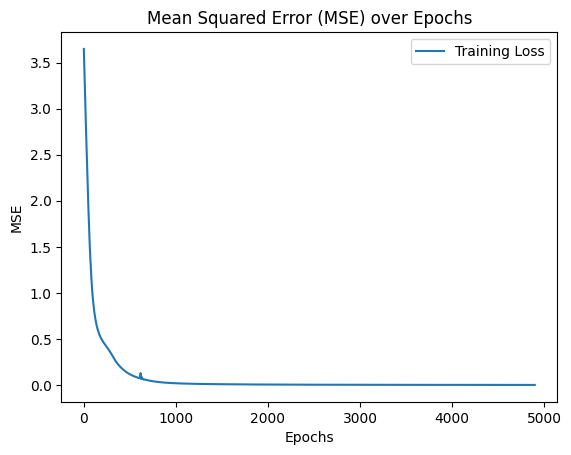

Function prediction took 0.0986 seconds
1/1 [==============================] - 0s 44ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 20ms/step 

1/1 [==============================] - 0s 22ms/step 

1/1 [==============================] - 0s 44ms/step                           

1/1 [==============================] - 0s 21ms/step                           

1/1 [==============================] - 0s 22ms/step                           

1/1 [==============================] - 0s 21ms/step                           

1/1 [==============================] - 0s 21ms/step                           

1/1 [==============================] - 0s 20ms/step                           

1/1 [==============================] - 0s 44ms/step                           

1/1 [==============================] - 0s 20ms/step                         

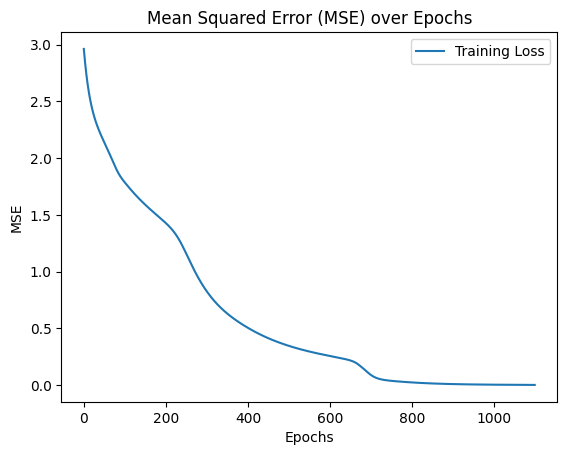

Function prediction took 0.1640 seconds
Function prediction took 0.1035 seconds


TypeError: 'module' object is not callable

In [7]:
if __name__ == "__main__":
    main()

NameError: name 'data' is not defined

In [3]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras




from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)



# Chosen example:
example="Discontinuous"
params = get_parameters(example)

x_values = np.linspace(0, 5, 1000)
# parameters 
deltas=params["deltas"]


plt.figure(figsize=(12, 8))
for delta in deltas:
    y_highfid = params["modified_highfid"](x_values,delta)
    y_lowfid = params["modified_lowfid"](x_values,delta)
    plt.plot(x_values, y_highfid, label=f'High Fidelity, delta={delta}')
    plt.plot(x_values, y_lowfid, label=f'Low Fidelity, delta={delta}', linestyle='--')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()



High Fidelity Function:
 @staticmethod
    def high_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        High fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated high fidelity values.
        """    
        lowfid = FidelityFunctions.low_fidelity_discontinuous(x)
        return (2*lowfid - 20*x/5 + 20) * (x/5 < 0.5) + (4 + 2*lowfid - 20*x/5 + 20) * (x/5 > 0.5) 

Low Fidelity Function:
 @staticmethod
    def low_fidelity_discontinuous(x: np.ndarray) -> np.ndarray:
        """
        Low fidelity function for the 'Discontinuous' case.
        
        :param x: Input array.
        :return: Calculated low fidelity values.
        """
        return (0.5 * (6.*x/5.-2.)**2 * np.sin(12.*x/5.-4) + 10.*(x/5-0.5) - 5.) * (x < 2.5) + \
               (3 + 0.5 * (6.*x/5.-2)**2 * np.sin(12.*x/5.-4) + 10 * (x/5.-0.5) - 5.) * (x > 2.5) 



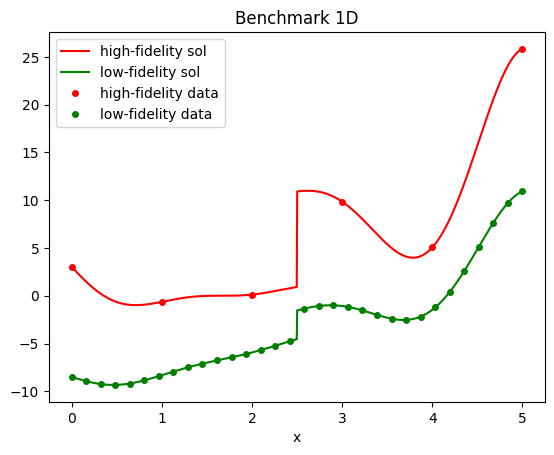

Function training took 10.5881 seconds
The function training took 10.588091135025024 seconds.


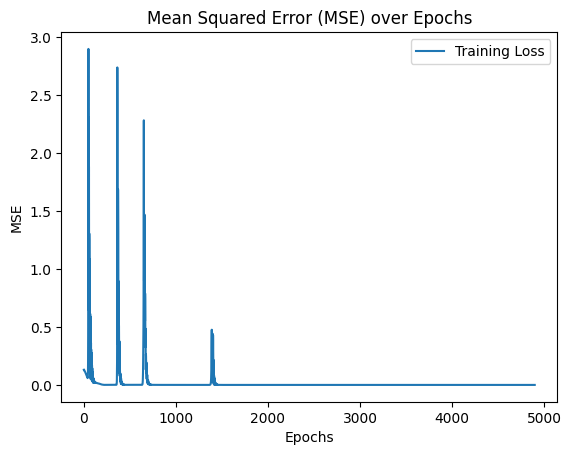

Function prediction took 0.1160 seconds
Function prediction took 0.0739 seconds
Test MSE: 82.28459782010431
R^2: -0.6799807891951397
Function training took 3.0053 seconds
The function training took 3.0062952041625977 seconds.


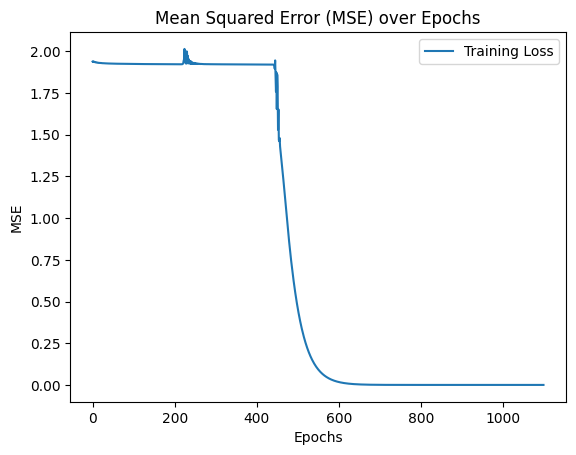

Function prediction took 0.1167 seconds
Function prediction took 0.0724 seconds
Test MSE: 3.500971598195358
R^2: 0.9285216773940531
Function training took 12.6845 seconds
The function training took 12.684470653533936 seconds.


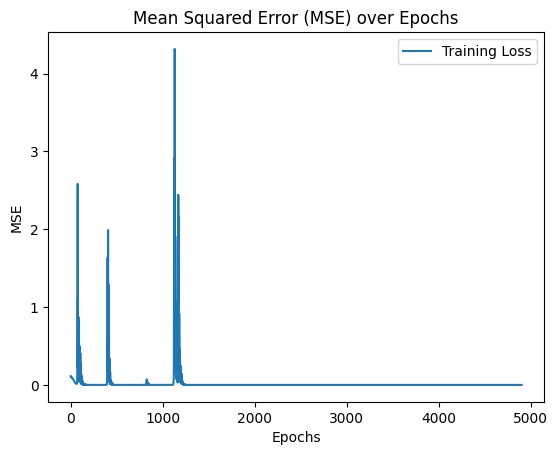

Function prediction took 0.0948 seconds
Function training took 3.0969 seconds
The function training took 3.0969414710998535 seconds.


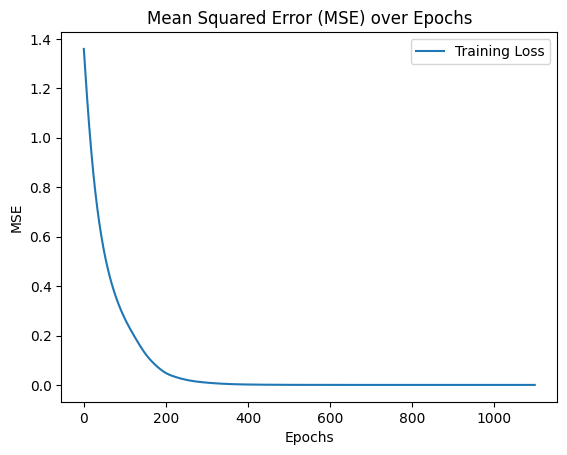

Function prediction took 0.1259 seconds
Function prediction took 0.0953 seconds
Function prediction took 0.0748 seconds
Function prediction took 0.0781 seconds
Test MSE: 5.638229056960772
R^2: 0.8848859111946509


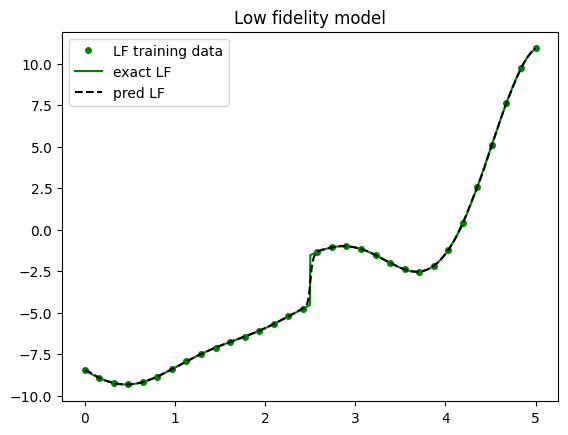

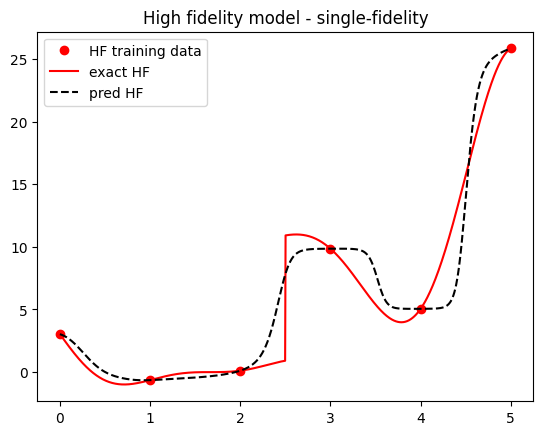

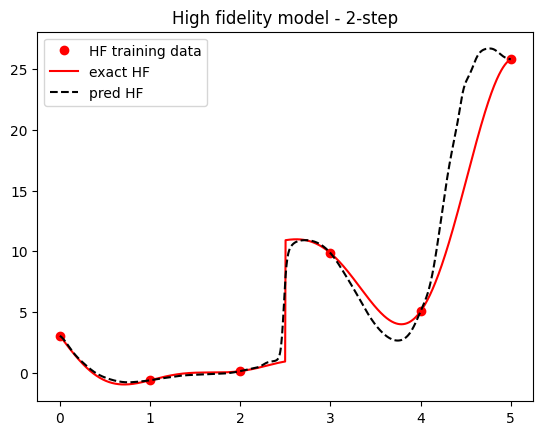

In [4]:
if __name__ == "__main__":
    main()

In [2]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras




from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure2 import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

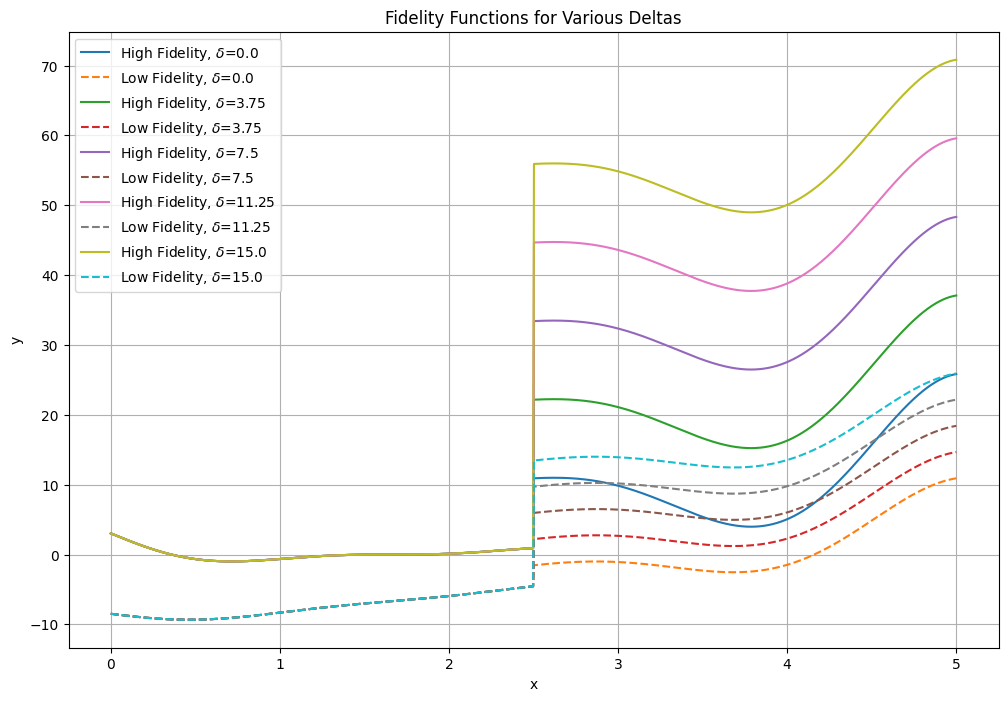

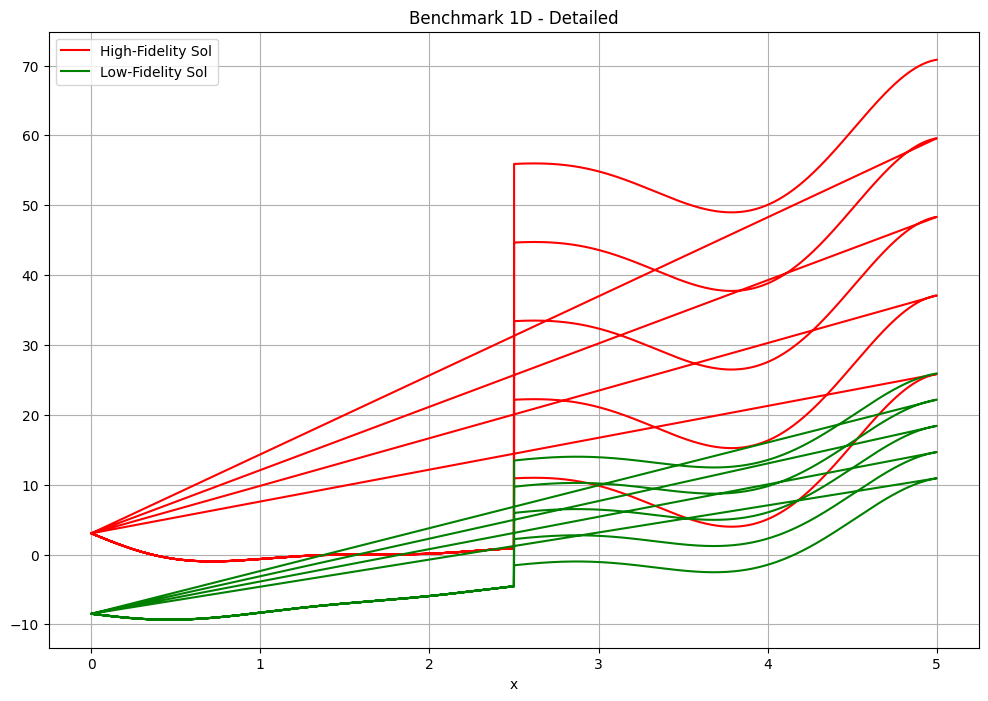

In [3]:
example = "Discontinuous"
fidelity_func = FidelityFunctionModified(example)
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()

In [4]:
data=fidelity_func.get_parameters(example)

In [5]:
data

{'modified_highfid': CPUDispatcher(<function FidelityFunctionModified.create_discontinuous_functions.<locals>.modified_highfid at 0x000001698DF26CA0>),
 'modified_lowfid': CPUDispatcher(<function FidelityFunctionModified.create_discontinuous_functions.<locals>.modified_lowfid at 0x000001698DF26E80>),
 'Nhf': 16,
 'Nlf': 40,
 'xhf': array([[ 0.        ,  0.        ],
        [ 0.33333333,  0.        ],
        [ 0.66666667,  0.        ],
        [ 1.        ,  0.        ],
        [ 1.33333333,  0.        ],
        [ 1.66666667,  0.        ],
        [ 2.        ,  0.        ],
        [ 2.33333333,  0.        ],
        [ 2.66666667,  0.        ],
        [ 3.        ,  0.        ],
        [ 3.33333333,  0.        ],
        [ 3.66666667,  0.        ],
        [ 4.        ,  0.        ],
        [ 4.33333333,  0.        ],
        [ 4.66666667,  0.        ],
        [ 5.        ,  0.        ],
        [ 0.        ,  3.75      ],
        [ 0.33333333,  3.75      ],
        [ 0.6666666

Function training took 15.0429 seconds
The function training took 15.04290509223938 seconds.


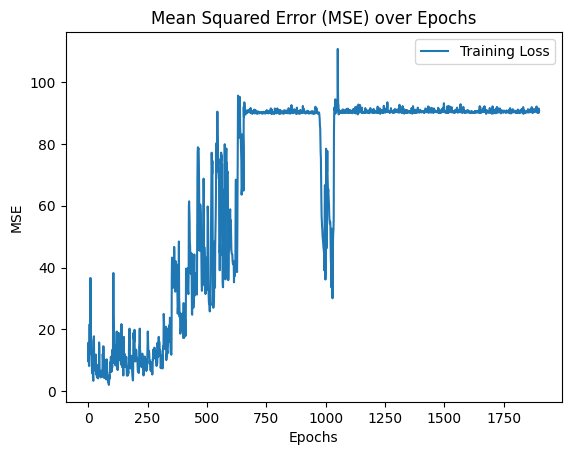

Test MSE: 697.3447278435988
R^2: -0.6470791638290372


Text(0.5, 1.0, 'Low fidelity model')

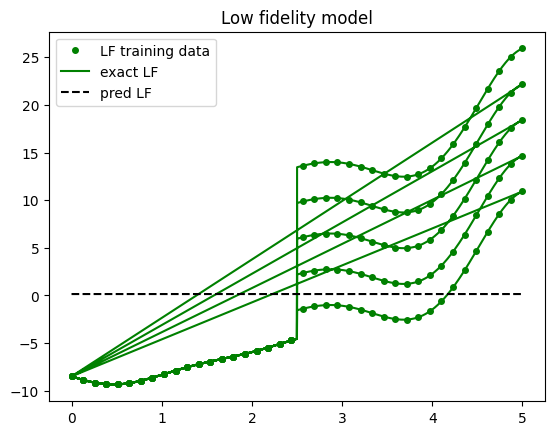

In [6]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_LF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xlf"],
        "output_train": data["Ylf"],
        "N": data["NepoLF"],
        "n": data["Nlf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
# building of the neural network
modelLF=NetworkFactory.build_network(**definition_LF)
# prediction step
yLF=modelLF.prediction(data["datatest"])
(mse_LF,R2_LF)=modelLF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xlf"][:,0],data["Ylf"],'go', label = 'LF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_lowfid"](data["datatest"][:,0],data["datatest"][:,1]),'g', label = 'exact LF') 
plt.plot(data["datatest"][:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

Function training took 35.2527 seconds
The function training took 35.253690004348755 seconds.


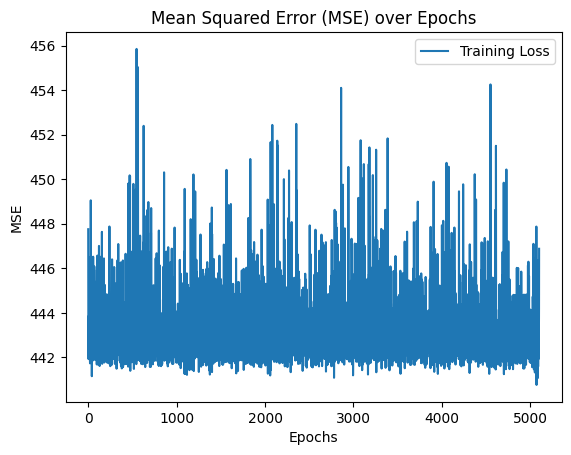

Test MSE: 423.3853328848127
R^2: -6.355854744732881e-06


Text(0.5, 1.0, 'High fidelity model')

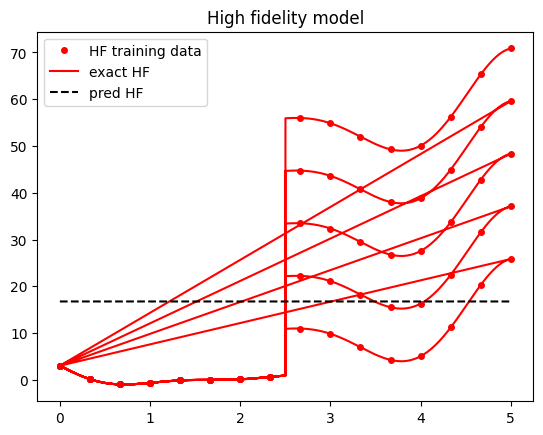

In [7]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_HF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xhf"],
        "output_train": data["Yhf"],
        "N": data["NepoHF"],
        "n": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
modelHF=NetworkFactory.build_network(**definition_HF)
yHF=modelHF.prediction(data["datatest"])
(mse_HF,R2_HF)=modelHF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],yHF,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')



Function training took 12.8453 seconds
The function training took 12.845282793045044 seconds.


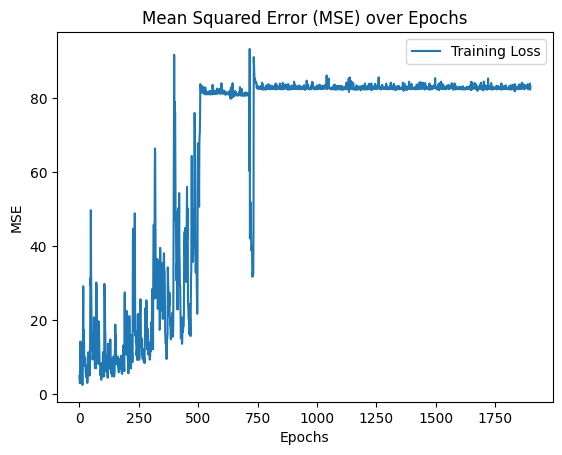

Function training took 25.4019 seconds
The function training took 25.401917219161987 seconds.


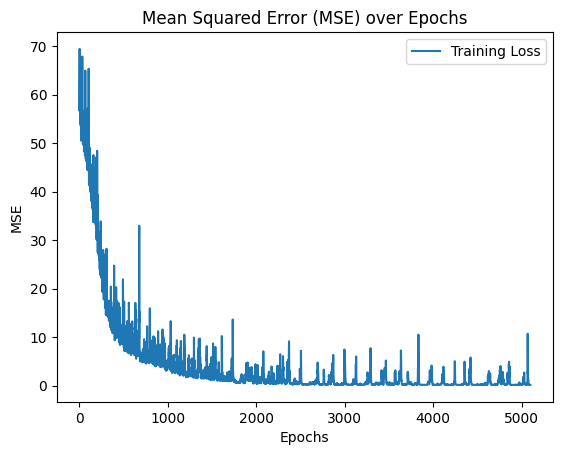

Test MSE: 7.523664246666331
R^2: 0.982229634610346


Text(0.5, 1.0, 'High fidelity model')

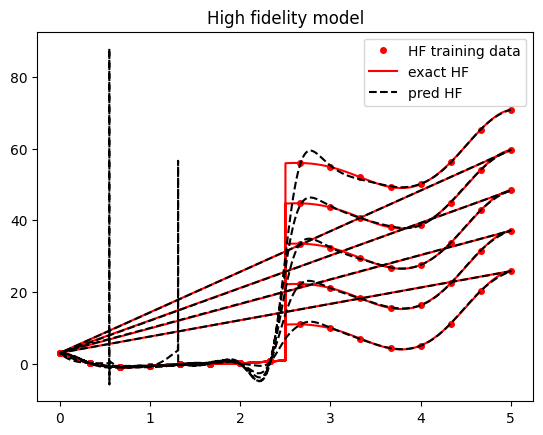

In [8]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)

if final_model == -1:
    raise ValueError("Failed to build the network. Check the network type and parameters.")

y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


# Prediction of a parameter 2 step nn

Sampling chain 1/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [04:45<00:00, 10.50it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:10<00:00,  9.65it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [14.365]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.365  0.273  13.858   14.884      0.014     0.01     363.0     285.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.635]



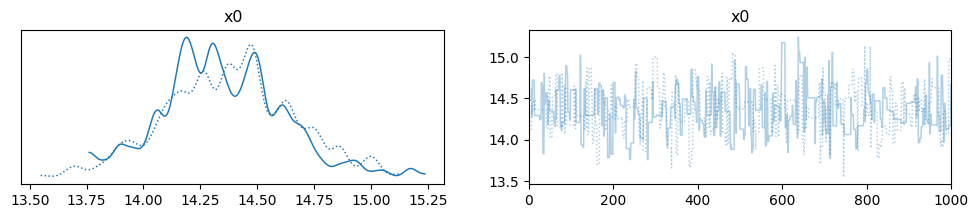

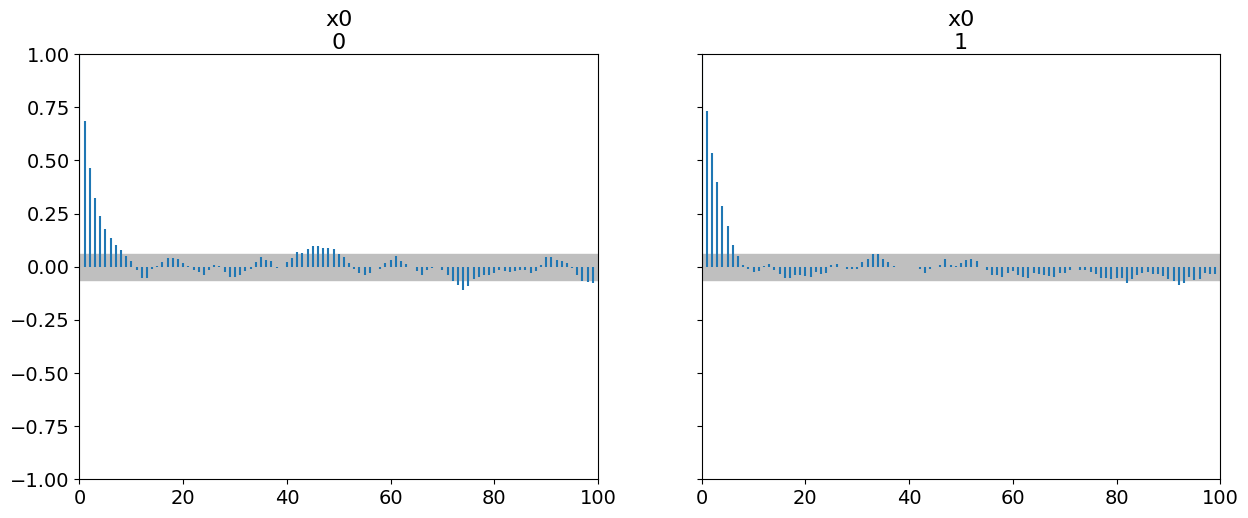

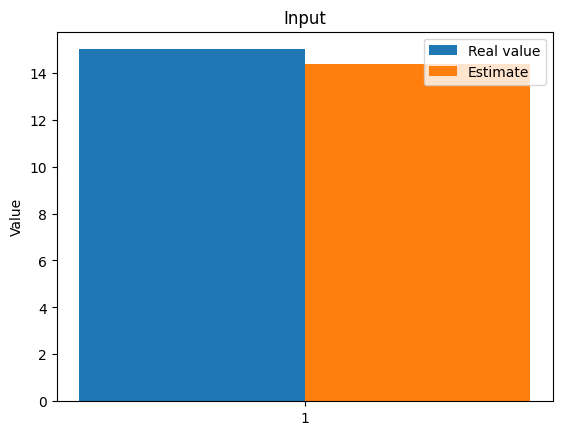

The function param_inverse took 610.8145380020142 seconds.
Sampling chain 1/2


Running chain, α = 0.27:  24%|██▍       | 720/3000 [01:16<04:03,  9.38it/s]


KeyboardInterrupt: 

In [10]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])

sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([15.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

# ricorda che i primi due non vanno bene in qualunque caso
estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)




In [11]:

# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
y_obs = data["Yhf"]
sd_noise = 0.1
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = 0.3
adapt = True
n_data = [30, 50]


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

nearest_x, y_obs = process_data(data["xhf"], parameters, x_data, Yhf) 

estimates = final_model.inverse_cuqi(
    mean_prior=mean_prior,
    x_real=x_real,
    y_obs=y_obs,
    N=N,
    burn_in=burn_in,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    scale=proposal_sd,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    x_data=x_data
)

NameError: name 'parameters' is not defined

In [26]:
data["Yhf"].shape

(80,)

In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = np.array([10, 20, 30, 40, 50])
sigma_noise = [0.1, 0.05]
n_data = [30, 50]
parameters = np.array([15.])
sigma = np.array([2., 4.])
rwmh_scaling = np.array([0.5, 1., 2.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

Sample 3000 / 3000

Average acceptance rate: 0.31 MCMC scale: 0.6249622686431184 

Mean values = [14.8533291]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.299 MCMC scale: 0.6130123585872429 

Mean values = [14.85638325]
(2, 1, 1000)


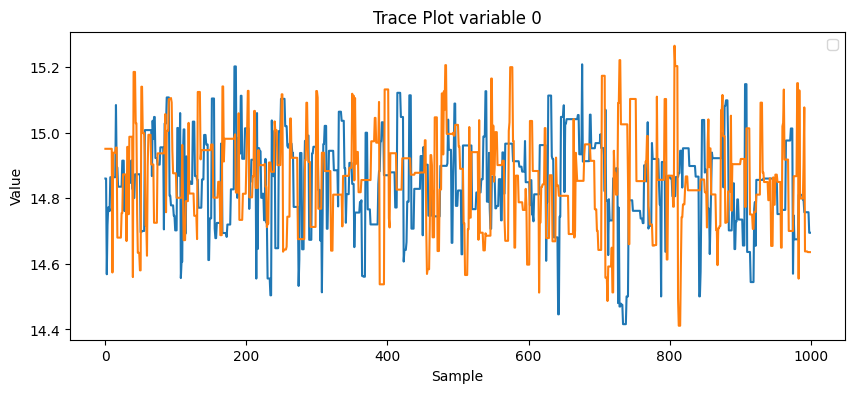

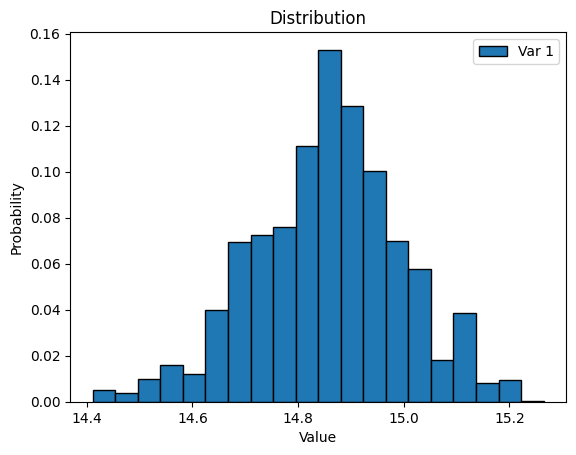

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 378.5746147278357


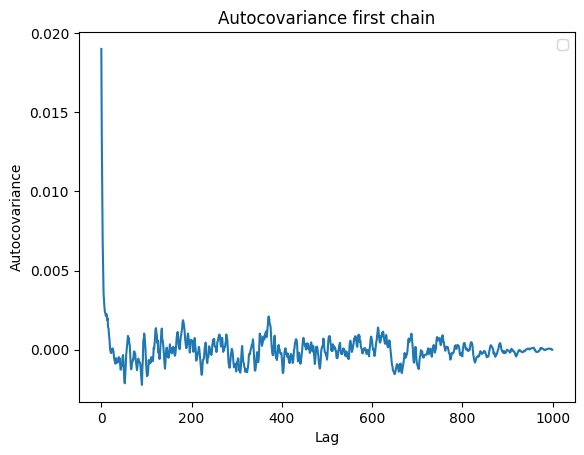

the difference between estimated values [0.14361675]



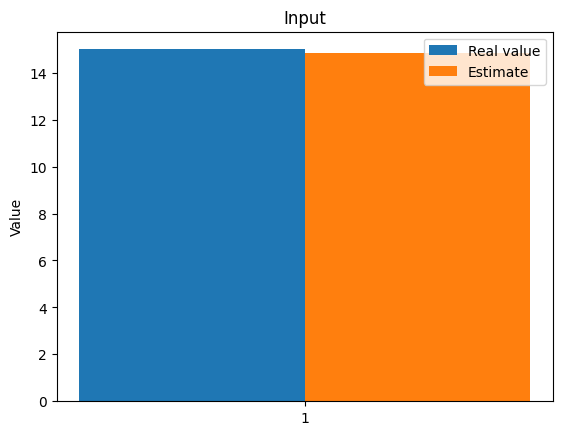

Sample 3000 / 3000

Average acceptance rate: 0.26 MCMC scale: 0.4367660225755193 

Mean values = [14.9228205]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.268 MCMC scale: 0.4541695530693019 

Mean values = [14.91729729]
(2, 1, 1000)


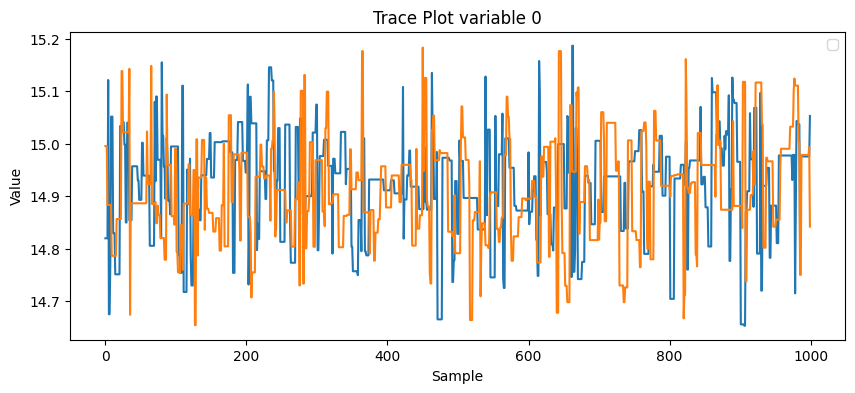

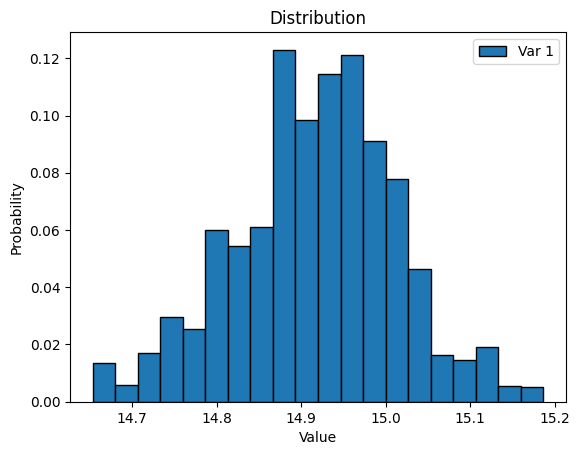

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 423.0425194756


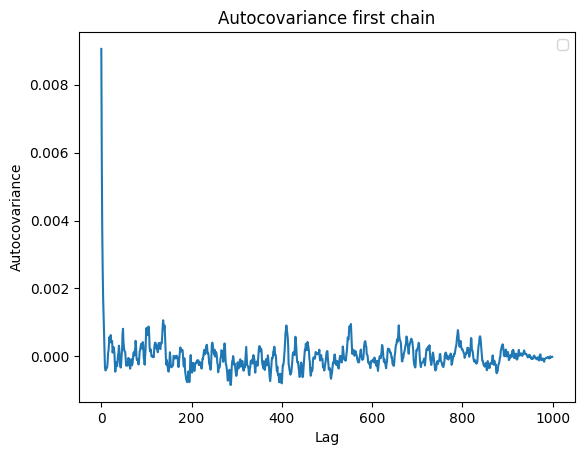

the difference between estimated values [0.08270271]



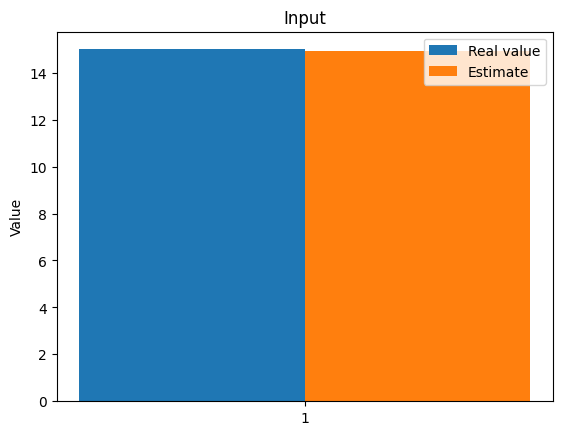

Sample 3000 / 3000

Average acceptance rate: 0.305 MCMC scale: 0.7763530803778186 

Mean values = [14.7505142]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.277 MCMC scale: 0.7344583613957313 

Mean values = [14.75779272]
(2, 1, 1000)


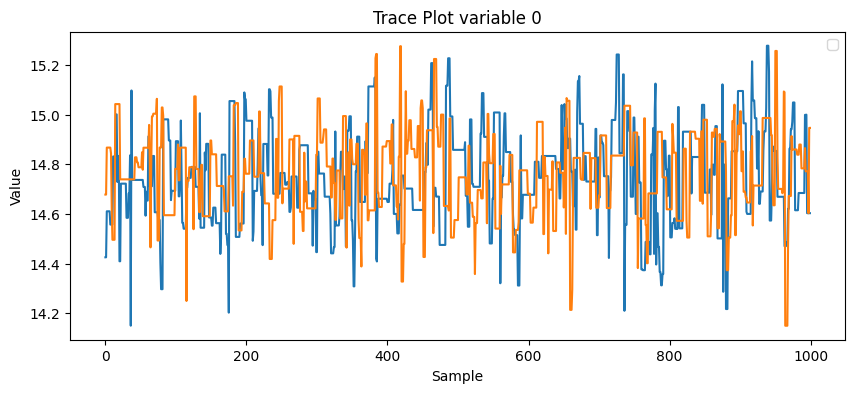

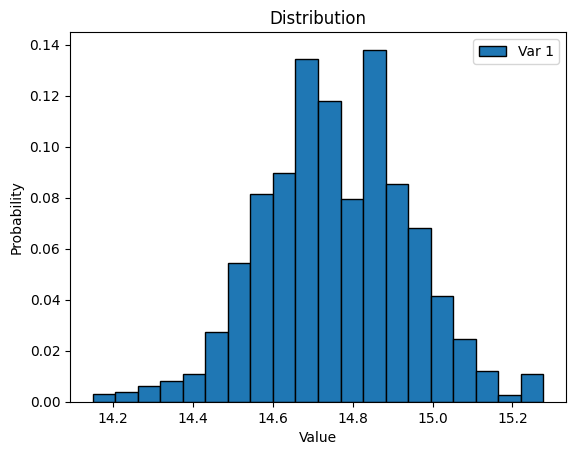

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 443.0052654580456


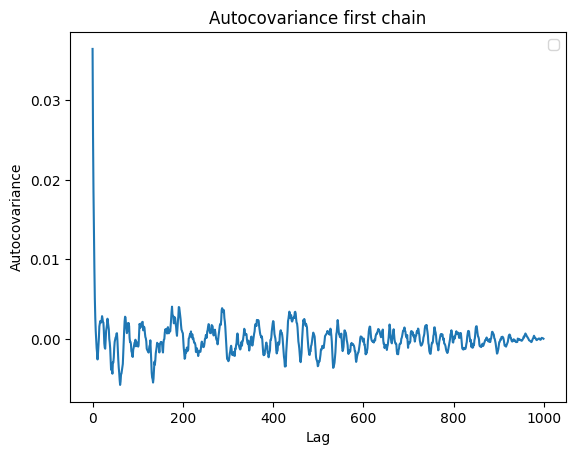

the difference between estimated values [0.24220728]



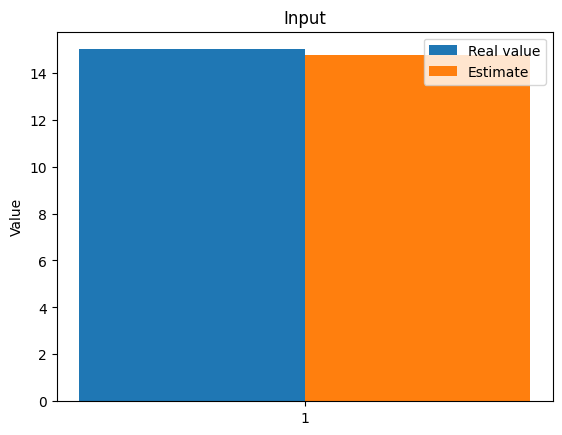

Sample 3000 / 3000

Average acceptance rate: 0.287 MCMC scale: 0.5578642808297212 

Mean values = [14.8650416]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.275 MCMC scale: 0.5949934253988892 

Mean values = [14.87005089]
(2, 1, 1000)


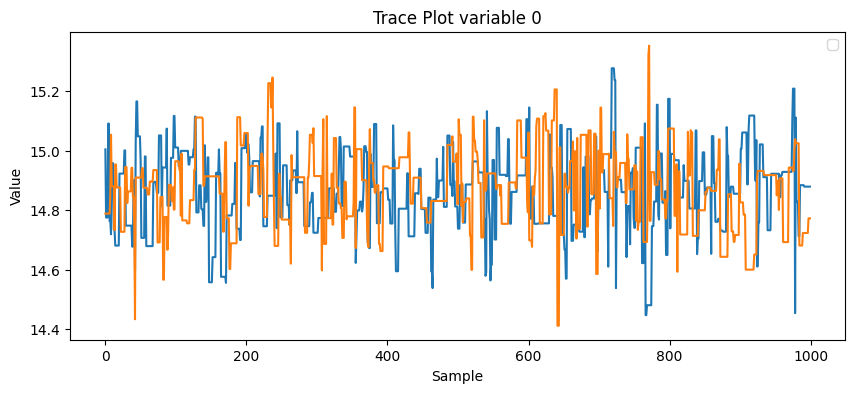

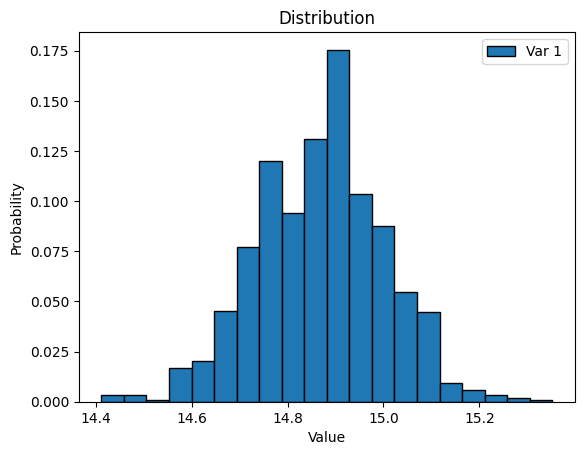

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 324.77619974295993


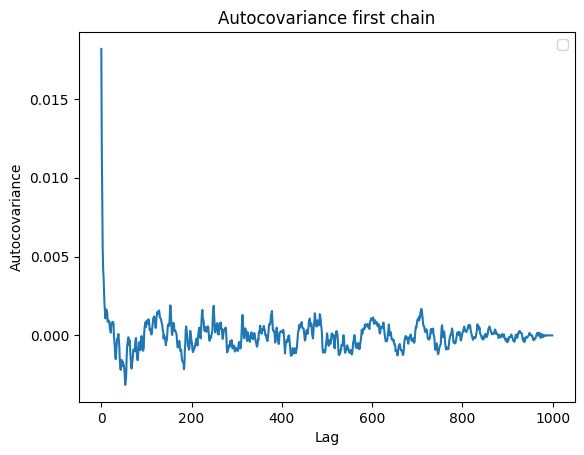

the difference between estimated values [0.12994911]



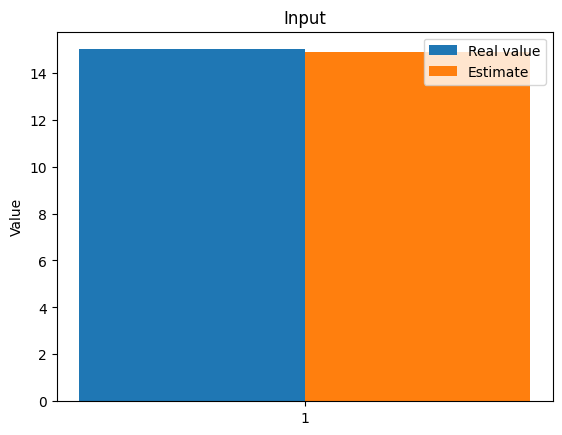

Sample 3000 / 3000

Average acceptance rate: 0.287 MCMC scale: 0.6360076776492017 

Mean values = [14.849556]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.308 MCMC scale: 0.6422882836555098 

Mean values = [14.84425001]
(2, 1, 1000)


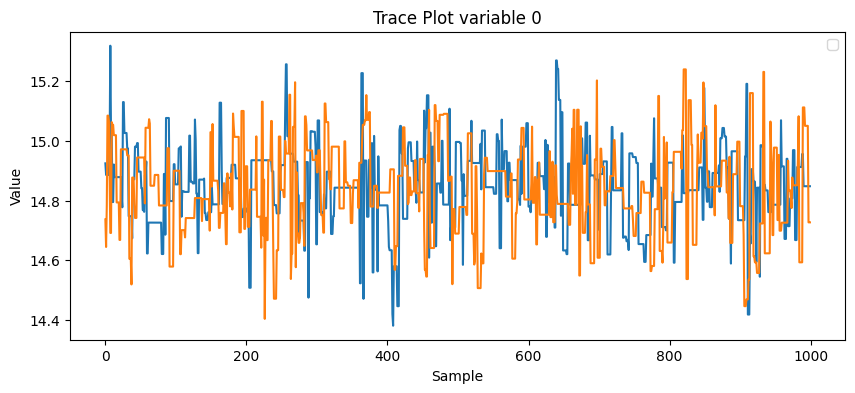

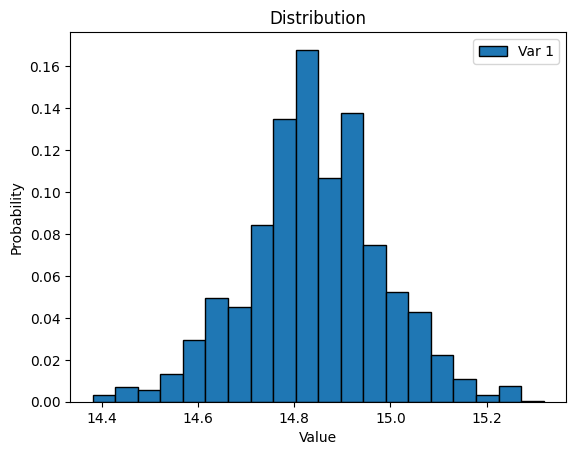

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 418.0888171575336


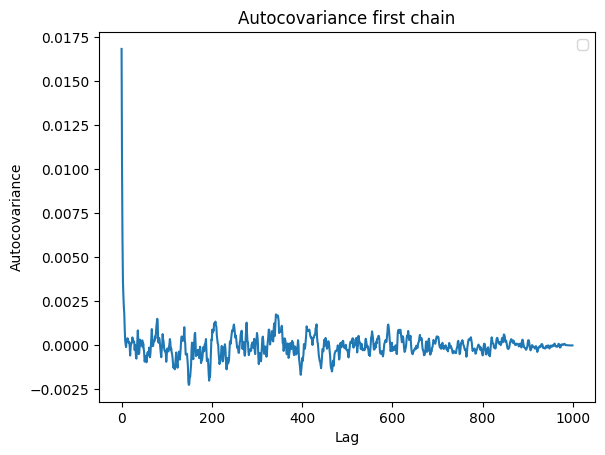

the difference between estimated values [0.15574999]



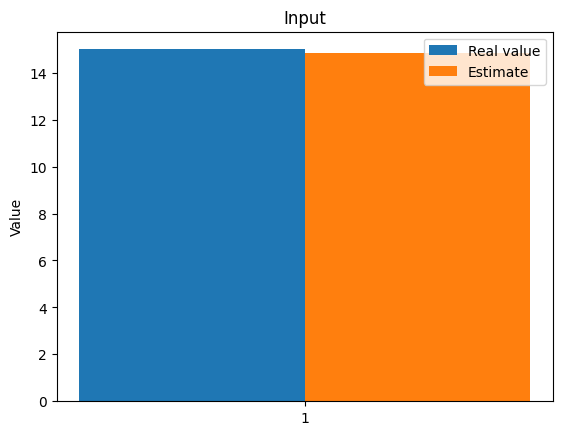

Sample 3000 / 3000

Average acceptance rate: 0.282 MCMC scale: 0.46465087216482126 

Mean values = [14.92725625]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.3 MCMC scale: 0.46064245220908323 

Mean values = [14.9289876]
(2, 1, 1000)


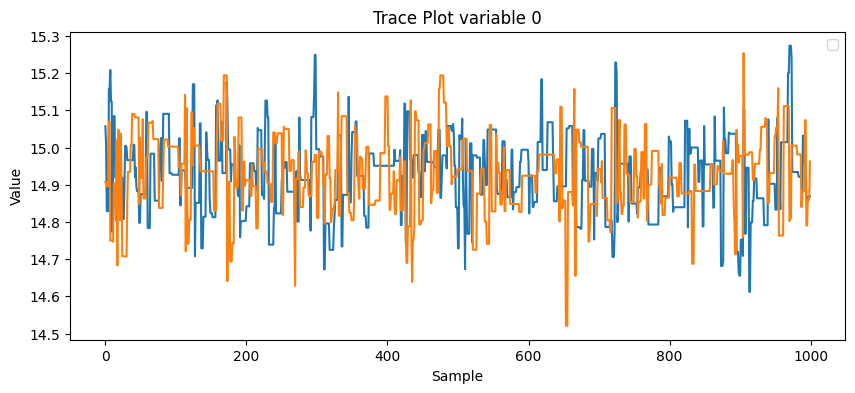

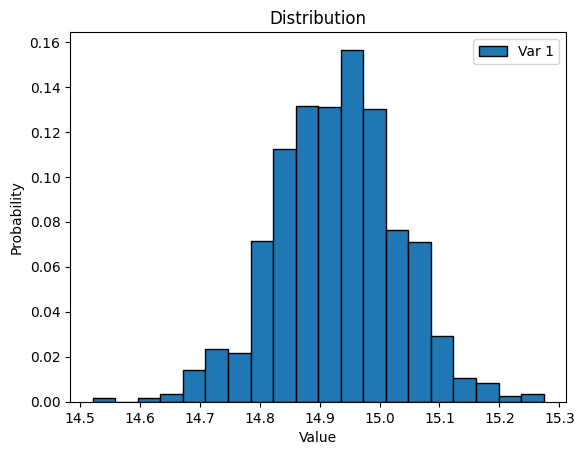

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 389.79802613337


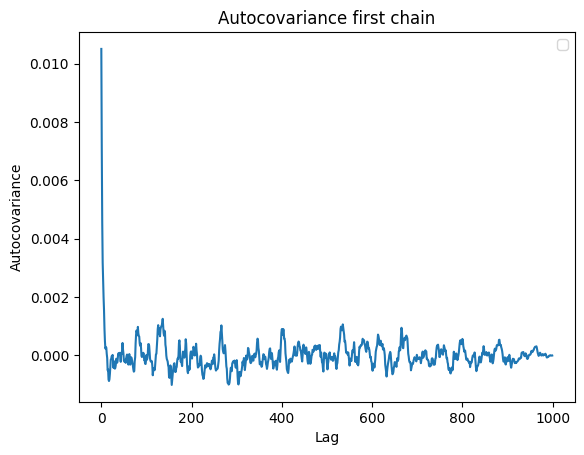

the difference between estimated values [0.0710124]



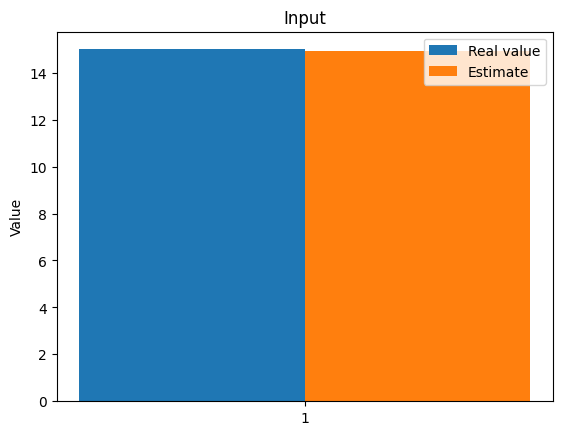

Sample 3000 / 3000

Average acceptance rate: 0.289 MCMC scale: 0.7922775411978211 

Mean values = [14.76791656]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.337 MCMC scale: 0.7632909606658906 

Mean values = [14.75423846]
(2, 1, 1000)


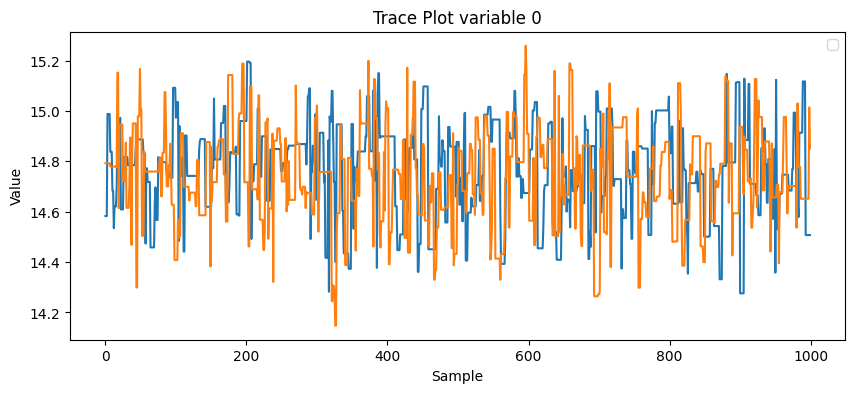

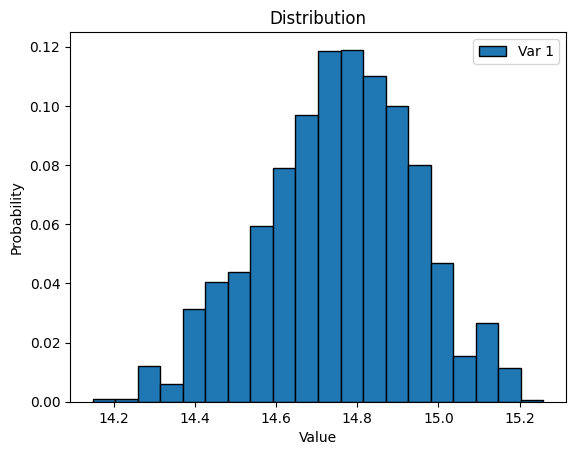

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 416.23731843630577


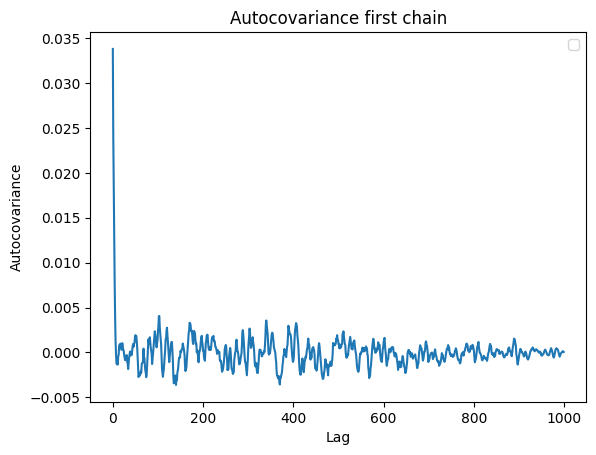

the difference between estimated values [0.24576154]



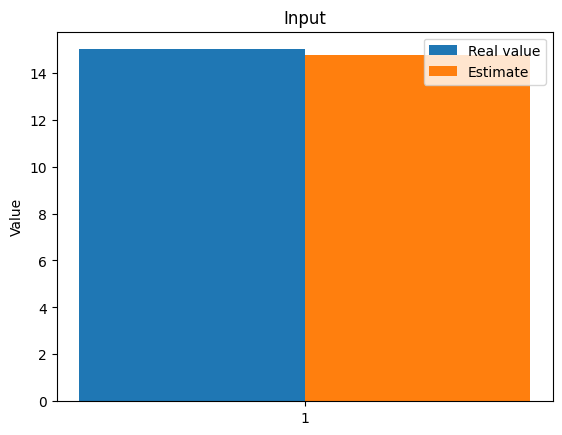

Sample 3000 / 3000

Average acceptance rate: 0.3 MCMC scale: 0.598474439023052 

Mean values = [14.88859857]
Sample 2970 / 3000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Sample 3000 / 3000

Average acceptance rate: 0.298 MCMC scale: 0.6395843175826605 

Mean values = [14.88477948]
(2, 1, 1000)


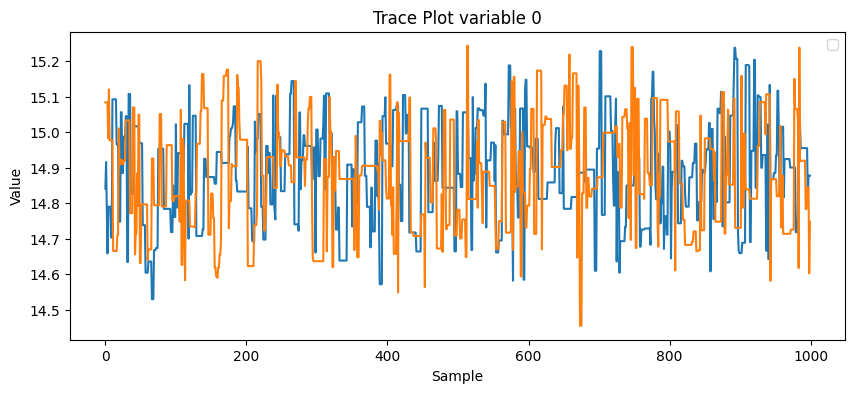

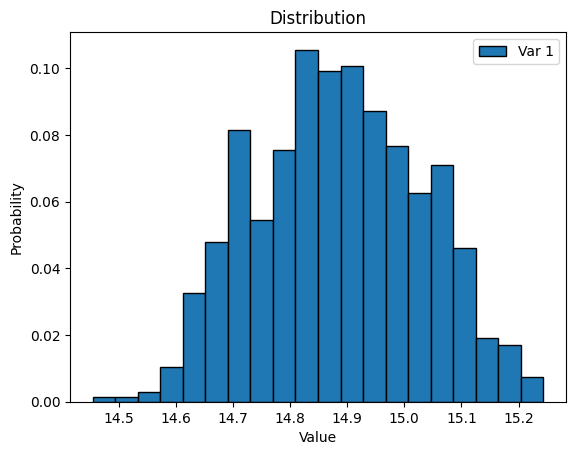

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 365.95467832527345


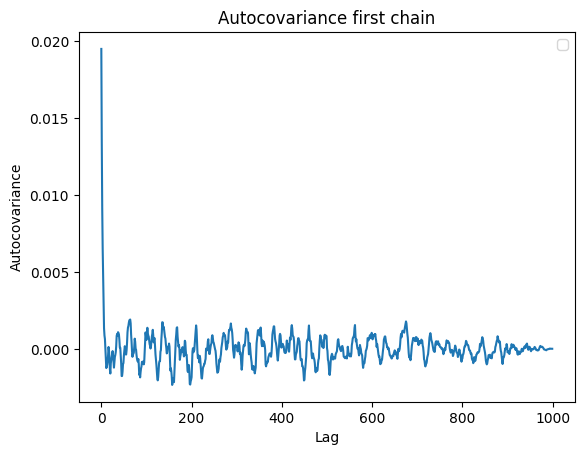

the difference between estimated values [0.11522052]



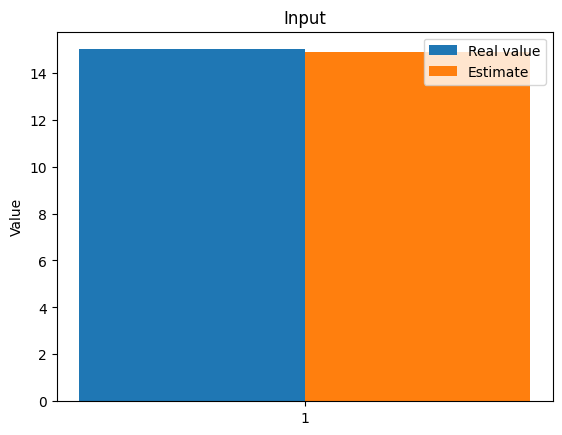

In [9]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 


In [ ]:
    @compute_time
    def inverse_cuqi(self, mean_prior: np.ndarray, x_data: np.ndarray, cov_prior: Optional[np.ndarray] = None,
                      cov_noise: float = 0.1, cov_likelihood: Optional[np.ndarray] = None, y_obs: Optional[np.ndarray] = None, 
                      x_real: Optional[np.ndarray] = None, number_chains: int = 1, N: int = 1000, burn_in: int = 500, 
                      levels: int = 1, diagnostic: bool = True, rwmh_cov: Optional[np.ndarray] = None, rwmh_scaling: float = 0.1, 
                      rwmh_adaptive: bool = True, algo: str = "MH", transformation: List[Any] = []) -> Tuple[np.ndarray, np.ndarray]:

        self.transformations = transformation
        self.inputs = x_data

        if x_real is not None:
            dim = x_real.shape[0]
        elif y_obs is not None:
            dim = y_obs.shape[0]
        else:
            warnings.warn("No observation nor data given", UserWarning)
            return np.array([]), np.array([])

        if N <= burn_in:
            warnings.warn("Number of steps insufficient, smaller or equal to burn-in", UserWarning)

        if cov_prior is None:
            cov_prior = np.diag(mean_prior * 0.2)

        if cov_likelihood is None:
            cov_likelihood = cov_noise**2 * np.eye(dim)

        my_prior = multivariate_normal(mean=mean_prior, cov=cov_prior)

        if y_obs is None:
            y_obs = self.wrapper_prediction(x_real) + np.random.normal(loc=0., scale=cov_noise, size=x_real.shape)
        else:
            y_obs += np.random.normal(loc=0., scale=cov_noise, size=y_obs.shape)
            y_obs = y_obs.flatten()

        if levels > 1:
            if levels > len(self.model_list):
                warnings.warn("Number of levels is exceeding the number of models", UserWarning)
            else:
                my_loglike = [Gaussian(mean=y_obs, cov=cov_likelihood) for _ in range(levels)]
                my_posterior = [JointDistribution(my_prior, my_loglike[i])(self.model_list[i].wrapper_prediction) for i in range(levels)]
        else:
            my_loglike = Gaussian(mean=y_obs, cov=cov_likelihood)
            my_posterior = JointDistribution(my_prior, my_loglike)(self.wrapper_prediction)

        if rwmh_cov is None:
            rwmh_cov = np.eye(dim)

        estimates = self.MCMC_cuqi(my_posterior, N, burn_in, number_chains, diagnostic, rwmh_cov, rwmh_scaling, rwmh_adaptive, algo, dim)

        if diagnostic:
            self.plot_hist(estimates, x_real, self.wrapper_prediction(estimates), self.wrapper_prediction(x_real))
        
        error = np.abs(estimates - x_real) / np.abs(x_real + 1e-10)
        return estimates, error

    def MCMC_cuqi(self, posterior, N, burn_in, n=1, diagnostic=True, rwmh_cov=None, rwmh_scaling=0.1, rwmh_adaptive=True, algo="MH", dim=1):
        
        x_init = np.random.rand(dim, n)
        estimates = np.empty((dim, 0))
        chains = np.empty((0, dim, N - burn_in))
        post = np.empty((dim, 0))

        for i in range(n):
            if algo == "NUTS":
                sampler = NUTS(posterior, x0=x_init[:, i])
            elif algo == "MH":
                if rwmh_adaptive:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
                else:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
            elif algo == "pCN":
                sampler = pCN(posterior, x0=x_init[:, i])
            else:
                raise ValueError("Unknown algorithm %s" % algo)
            
            if rwmh_adaptive:
                samples = sampler.sample_adapt(N - burn_in, burn_in)
            else:
                samples = sampler.sample(N - burn_in, burn_in)

            estimates = np.column_stack((estimates, samples.mean()[:, np.newaxis]))
            chains = np.concatenate((chains, np.expand_dims(samples.samples, axis=0)), axis=0)
            post = np.concatenate((post, samples.samples), axis=1)

            print(f"Mean values = {estimates.mean(axis=1)}")

        print(chains.shape)
        for l in range(chains.shape[1]):
            plt.figure(figsize=(10, 4))
            for i in range(chains.shape[0]):
                plt.plot(chains[i, l, :])
            plt.xlabel('Sample')
            plt.ylabel('Value')
            plt.title(f'Trace Plot variable {l}')
            plt.legend()
            plt.show()
        
        if diagnostic:
            if n == 1:
                samples.plot_trace()
                samples.plot_autocorrelation()
            else:
                num_bins = 20
                plt.figure()
                for num in range(post.shape[0]):        
                    bin_edges = np.linspace(np.min(post[num, :]), np.max(post[num, :]), num_bins + 1)
                    hist, _ = np.histogram(post[num, :], bins=bin_edges)
                    hist = hist / post.shape[1]
                    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                    plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')
                    plt.xlabel('Value')
                    plt.ylabel('Probability')
                    plt.title('Distribution')
                    plt.legend()
                    plt.show()
                
                autocov = arviz.autocov(chains[:, 0, :])
                ess = arviz.ess(chains[:, 0, :])
                print(f"ESS values = {ess}")
                plt.figure()
                plt.plot(autocov[0, :])
                plt.title('Autocovariance first chain')
                plt.xlabel('Lag')
                plt.ylabel('Autocovariance')
                plt.legend()
                plt.show()
        
        return estimates